In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids
from sklearn.decomposition import PCA
import seaborn as sns

# Wczytanie danych
file_path = 'BathSoap.xlsx'
df = pd.read_excel(file_path, sheet_name="DM_Sheet")

# Ustawienie nagłówków i oczyszczenie danych
df.columns = df.iloc[1]  # właściwe nagłówki
df_cleaned = df.iloc[2:].reset_index(drop=True)
df_cleaned.columns = df_cleaned.columns.str.strip()  # usuń spacje z nazw kolumn

# Sprawdzenie braków i duplikatów
print("Braki danych:\n", df_cleaned.isnull().sum()[lambda x: x > 0])
print(f"\nLiczba zduplikowanych wierszy: {df_cleaned.duplicated().sum()}")
print("\nTypy danych:\n", df_cleaned.dtypes)

# Zmienne do klasteryzacji
behavior_cols = [
    'No. of Brands', 'Brand Runs', 'Total Volume', 'No. of  Trans', 'Value',
    'Trans / Brand Runs', 'Vol/Tran', 'Avg. Price',
    'Pur Vol No Promo - %', 'Pur Vol Promo 6 %', 'Pur Vol Other Promo %'
]

# Tworzenie macierzy X z wartościami liczbowymi
X = df_cleaned[behavior_cols].apply(pd.to_numeric, errors='coerce').dropna()

# Konwersja na liczby + usunięcie braków
print("\nBraki danych po konwersji:\n", X.isnull().sum())
X = X.dropna()

# Statystyki opisowe
desc = X.describe().T
desc["CV"] = (X.std() / X.mean()).round(3)
desc["Skewness"] = X.skew().round(3)
desc["Kurtosis"] = X.kurt().round(3)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(desc.round(3))

# Normalizacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Braki danych:
 1
Member id                2
SEC                      2
FEH                      2
MT                       2
SEX                      2
AGE                      2
EDU                      2
HS                       2
CHILD                    2
CS                       2
Affluence Index          2
No. of Brands            2
Brand Runs               2
Total Volume             1
No. of  Trans            2
Value                    2
Trans / Brand Runs       2
Vol/Tran                 2
Avg. Price               2
Pur Vol No Promo - %     2
Pur Vol Promo 6 %        2
Pur Vol Other Promo %    2
Br. Cd. 57, 144          2
Br. Cd. 55               2
Br. Cd. 272              2
Br. Cd. 286              2
Br. Cd. 24               2
Br. Cd. 481              2
Br. Cd. 352              2
Br. Cd. 5                2
Others 999               2
Pr Cat 1                 2
Pr Cat 2                 2
Pr Cat 3                 2
Pr Cat 4                 2
PropCat 5                2
PropCat 6  

,count,mean,std,min,25%,50%,75%,max,CV,Skewness,Kurtosis
1,,,,,,,,,,,
No. of Brands,600.0,3.637,1.580,1.000,2.000,3.000,5.000,9.000,0.434,0.520,-0.104
Brand Runs,600.0,15.752,10.396,1.000,8.000,15.000,21.000,74.000,0.660,1.324,3.626
Total Volume,600.0,11914.770,7770.375,150.000,6825.000,10360.000,15343.750,50895.000,0.652,1.450,3.530
No. of Trans,600.0,31.153,17.427,1.000,22.000,28.000,40.000,138.000,0.559,1.265,4.035
Value,600.0,1337.386,883.155,20.000,789.562,1216.000,1675.750,6371.850,0.660,1.870,6.595
Trans / Brand Runs,600.0,2.618,2.605,1.000,1.420,1.843,2.689,23.000,0.995,4.659,28.074
Vol/Tran,600.0,415.051,248.761,94.431,250.513,361.525,490.885,2525.000,0.599,2.633,12.535
Avg. Price,600.0,11.835,3.743,5.624,9.762,11.250,13.421,33.325,0.316,1.301,3.922
Pur Vol No Promo - %,600.0,0.913,0.119,0.000,0.879,0.953,1.000,1.000,0.131,-2.500,9.296


<Figure size 1200x600 with 0 Axes>

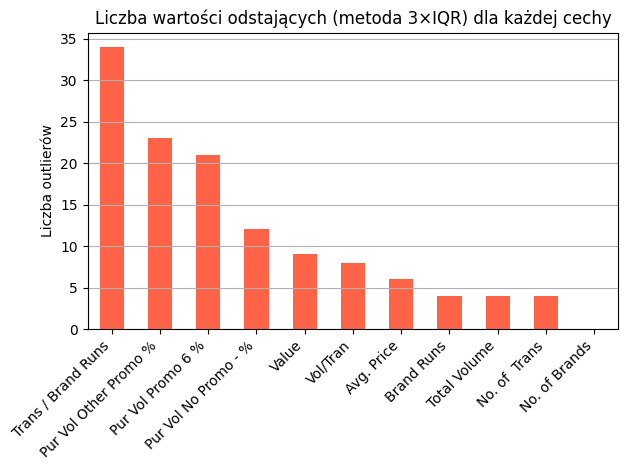

In [3]:
np.random.seed(42)

# Zliczanie liczby outlierów w każdej zmiennej wg reguły 3*IQR
outlier_counts = {}

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    is_outlier = (X[col] < lower_bound) | (X[col] > upper_bound)
    outlier_counts[col] = is_outlier.sum()

# Zamiana na DataFrame do wykresu
outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Liczba Outlierów'])
outlier_df = outlier_df.sort_values(by='Liczba Outlierów', ascending=False)

# Wykres słupkowy
plt.figure(figsize=(12, 6))
outlier_df.plot(kind='bar', legend=False, color='tomato')
plt.title('Liczba wartości odstających (metoda 3×IQR) dla każdej cechy')
plt.ylabel('Liczba outlierów')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()


W analizie wykryto wartości odstające na poziomie do 6% w wybranych cechach (wg metody 3×IQR). 
Zamiast ich usuwania, zastosowano metode K-medoids w celu ograniczenia ich wpływu na grupowanie.

Metoda łokcia + Indeks Sylwetki

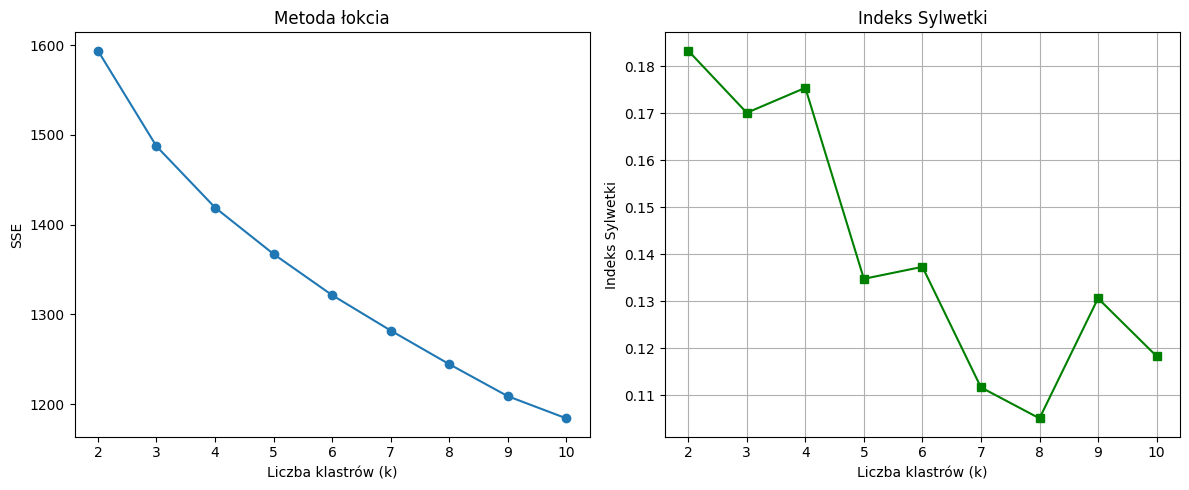

In [4]:
# Skalowanie odporne na outliery
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Klasteryzacja K-medoids
sse_robust = []
silhouette_robust = []
k_range = range(2, 11)

for k in k_range:
    kmedoids = KMedoids(n_clusters=k, random_state=42, method='pam')
    labels = kmedoids.fit_predict(X_scaled)
    sse_robust.append(kmedoids.inertia_)
    silhouette_robust.append(silhouette_score(X_scaled, labels))

# Wykres
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, sse_robust, marker='o')
plt.title("Metoda łokcia")
plt.xlabel("Liczba klastrów (k)")
plt.ylabel("SSE")

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_robust, marker='s', color='green')
plt.title("Indeks Sylwetki")
plt.xlabel("Liczba klastrów (k)")
plt.ylabel("Indeks Sylwetki")

plt.tight_layout()
plt.grid(True)
plt.show()


Analizując oba wykresy – metodę łokcia oraz indeks sylwetki – najlepszymi kandydatami są k = 4 lub k = 5.
Choć przy k = 5 wartość indeksu sylwetki spada nieznacznie, to jednocześnie następuje znaczna redukcja błędu (SSE) wzgledem 4.
Z tego względu optymalnym wyborem pozostaje 5 klastrów, jako kompromis między zwartą strukturą a dokładnością podziału.

In [5]:
# Finalny model z wybranym k
optimal_k = 5
kmedoids_final = KMedoids(n_clusters=optimal_k, method='pam', random_state=42)
clusters = kmedoids_final.fit_predict(X_scaled)

# Dodanie etykiet klastrów do oryginalnych danych
X['Cluster'] = clusters
df_cleaned_clustered = df_cleaned.loc[X.index].copy()
df_cleaned_clustered['Cluster'] = clusters


In [6]:
print(X.groupby('Cluster').mean().round(2))
print(X['Cluster'].value_counts())

1        No. of Brands  Brand Runs  Total Volume  No. of  Trans    Value  \
Cluster                                                                    
0                 3.13       13.01       9314.52          26.70  1185.39   
1                 3.73       20.37       8997.29          32.02  1139.12   
2                 5.27       25.28      13393.11          46.39  1552.15   
3                 3.63       15.66      27589.00          36.74  2837.56   
4                 2.24        5.43       7158.74          14.85   608.66   

1        Trans / Brand Runs  Vol/Tran  Avg. Price  Pur Vol No Promo - %  \
Cluster                                                                   
0                      2.38    360.23       13.38                  0.92   
1                      1.72    305.21       13.21                  0.66   
2                      2.04    305.44       11.83                  0.93   
3                      3.12    847.31       10.15                  0.94   
4                

KLASTER 0 (186)
Umiarkowani użytkownicy: średnia aktywność zakupowa (Trans = 26.7, Brands = 3.13) i wartość (Value = 1185.39).
Wysoka lojalność (No Promo = 92%), bardzo mało promocji (Promo 6% = 3%), kupują raczej drożej (Avg. Price = 13.38).

KLASTER 1 (59)
Promocyjny segment: przeciętna aktywność (Trans = 32), ale wysoka podatność na promocje (Promo 6% = 27%).
Niska lojalność (No Promo = 66%), średnia cena (Avg. Price = 13.21), wartość zakupów umiarkowana (Value = 1139.12).

KLASTER 2 (163)
Najbardziej aktywni i lojalni klienci: najwyższa liczba marek (5.27), transakcji (46.39) i wysoka wartość zakupów (1552.15).
Bardzo lojalni (No Promo = 93%), promocje marginalne (Promo 6% = 5%), kupują w dobrej cenie (Avg. Price = 11.83).

KLASTER 3 (65)
Masowi, lojalni kupujący o wysokim wolumenie (Volume = 27 589) i najwyższej wartości (Value = 2837.56).
Lojalni (No Promo = 94%), mało promocji (Promo 6% = 3%), najniższa cena zakupu (Avg. Price = 10.15).

KLASTER 4 (127)
Najmniej aktywni: najniższa liczba marek (2.24) i transakcji (14.85), niska wartość zakupów (608.66).
Bardzo lojalni (No Promo = 98%), praktycznie brak promocji (Promo 6% = 1%), kupują najtaniej (Avg. Price = 9.81).

Analiza charakterystyki klastrów

In [7]:
# Przygotowanie rozkładów
age_dist = df_cleaned_clustered.groupby('Cluster')['AGE'].value_counts(normalize=True).round(2).unstack().fillna(0)
sex_dist = df_cleaned_clustered.groupby('Cluster')['SEX'].value_counts(normalize=True).round(2).unstack().fillna(0)
sec_dist = df_cleaned_clustered.groupby('Cluster')['SEC'].value_counts(normalize=True).round(2).unstack().fillna(0)

# Etykiety kolumn
age_dist.columns = [f'AGE_{int(c)}' for c in age_dist.columns]
sex_dist.columns = [f'SEX_{int(c)}' for c in sex_dist.columns]
sec_dist.columns = [f'SEC_{int(c)}' for c in sec_dist.columns]

# Połączenie w jedną tabelę
cluster_summary = pd.concat([age_dist, sex_dist, sec_dist], axis=1)

# Wyświetlenie
print(cluster_summary.round(2))


         AGE_1  AGE_2  AGE_3  AGE_4  SEX_0  SEX_1  SEX_2  SEC_1  SEC_2  SEC_3  \
Cluster                                                                         
0         0.01   0.23   0.33   0.43   0.10   0.05   0.85   0.27   0.25   0.26   
1         0.00   0.15   0.27   0.58   0.05   0.02   0.93   0.34   0.37   0.17   
2         0.04   0.20   0.28   0.48   0.02   0.06   0.91   0.23   0.29   0.26   
3         0.03   0.12   0.22   0.63   0.02   0.00   0.98   0.15   0.20   0.31   
4         0.04   0.28   0.25   0.43   0.33   0.01   0.66   0.26   0.16   0.22   

         SEC_4  
Cluster         
0         0.22  
1         0.12  
2         0.21  
3         0.34  
4         0.36  


**AGE = 1 to najmłodsze osoby, AGE = 4 to najstarsze osoby**

- Klaster 0: 43% AGE 4, 33% AGE 3 – przewaga starszych i średnich grup wiekowych
- Klaster 1: 58% AGE 4 – dominują osoby starsze
- Klaster 2: 48% AGE 4, 28% AGE 3 – również przewaga starszych
- Klaster 3: 63% AGE 4 – zdecydowanie najstarszy segment
- Klaster 4: 28% AGE 2, 25% AGE 3, 43% AGE 4 – bardziej zrównoważony, ale najmłodszy w porównaniu z innymi

**SEX = 0 męzczyźni, SEX = 2 kobiety SEX = 1 brak danych**

- Klaster 0: 85% kobiet, 10% mężczyzn – silna przewaga kobiet
- Klaster 1: 93% kobiet, 5% mężczyzn – bardzo sfeminizowany
- Klaster 2: 91% kobiet – również bardzo sfeminizowany
- Klaster 3: 98% kobiet – niemal wyłącznie kobiety
- Klaster 4: 66% kobiet, 33% mężczyzn – bardziej zrównoważony, ale kobiety nadal dominują

**SEC = 1 – najwyższy status społeczno-ekonomiczny, SEC = 4 – najniższy (im wyższy numer, tym niższy status)**

- Klaster 0: zrównoważony – 27% SEC 1, 25% SEC 2, 26% SEC 3
- Klaster 1: przewaga wyższego statusu – 34% SEC 1, 37% SEC 2
- Klaster 2: mieszany – po ok. 25–30% w każdej kategorii
- Klaster 3: niższe warstwy – 31% SEC 3, 34% SEC 4
- Klaster 4: najniższy status – 36% SEC 4, 26% SEC 3

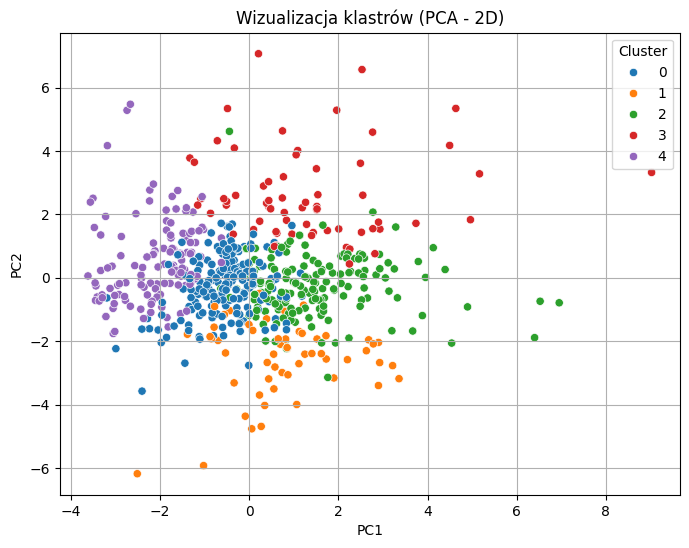

In [8]:
# PCA na danych X_scaled
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Tworzenie DataFrame z komponentami i klastrami
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

# Wykres
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10')
plt.title('Wizualizacja klastrów (PCA - 2D)')
plt.grid(True)
plt.show()


Wizualizacja potwierdza, że podział na 5 klastrów dobrze odwzorowuje zróżnicowanie w danych. Klastry różnią się zarówno rozmiarem, jak i rozproszeniem — co może wskazywać na różne typy zachowań konsumenckich i potencjały marketingowe.

#### Grupowanie hierarchiczne


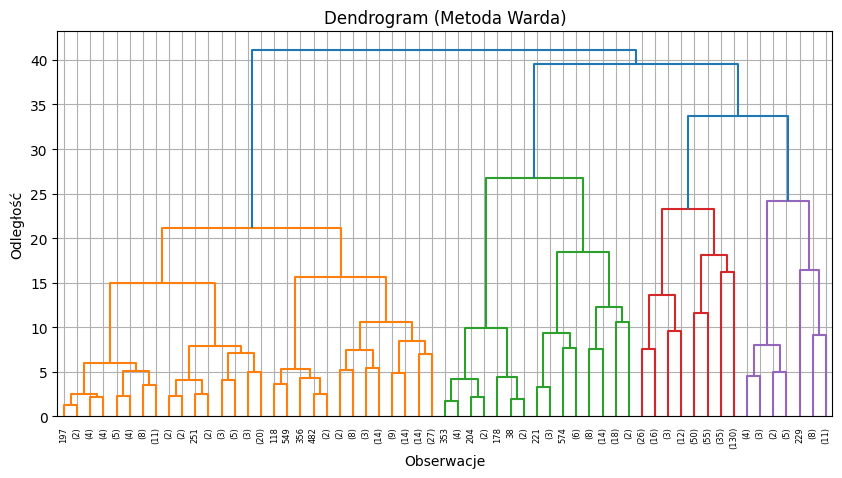

In [9]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_matrix = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title("Dendrogram (Metoda Warda)")
plt.xlabel("Obserwacje")
plt.ylabel("Odległość")
plt.grid(True)
plt.show()



Powyższy dendrogram wskazuje na liczbę klastrów równą 4, dlatego do tej metody grupowania, czyli hierarchicznej użyto właśnie 4 klastrów.

In [12]:
# Klasteryzacja 
k_hier = 4
hier_model = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
labels_hier = hier_model.fit_predict(X_scaled)

# Dodanie etykiet klastrów do oryginalnych danych
X['Cluster_Hier'] = labels_hier
df_cleaned_clustered_hier = df_cleaned.loc[X.index].copy()
df_cleaned_clustered_hier['Cluster_Hier'] = labels_hier

# Wyświetlenie statystyk klastrów
print(X.groupby('Cluster_Hier').mean().round(2))
print("\nLiczność klastrów:\n", X['Cluster_Hier'].value_counts())



1             No. of Brands  Brand Runs  Total Volume  No. of  Trans    Value  \
Cluster_Hier                                                                    
0                      2.86       10.35      25189.54          31.18  2457.18   
1                      3.01       11.25       8887.60          24.35  1026.21   
2                      2.97       11.88       7456.47          19.97   868.53   
3                      5.23       26.99      13515.96          46.11  1595.48   

1             Trans / Brand Runs  Vol/Tran  Avg. Price  Pur Vol No Promo - %  \
Cluster_Hier                                                                   
0                           6.03    888.20        9.32                  0.96   
1                           2.45    381.61       12.06                  0.95   
2                           2.07    387.93       12.27                  0.59   
3                           1.76    306.44       12.27                  0.89   

1             Pur Vol Promo 6 % 

Opis 4 klastrów: 

KLASTER 0 (65) – Masowi lojalni kupujący: najwyższa wartość zakupów (Value = 2457.18) i bardzo wysoki wolumen (Volume = 25 190). 
 Wysoka aktywność (Trans = 31.18), ale niewielka liczba marek (Brands = 2.86). 
 Bardzo lojalni (No Promo = 96%), promocje rzadko (Promo 6% = 2%), kupują najtaniej (Avg. Price = 9.32). 

KLASTER 1 (327) – Umiarkowani użytkownicy: najliczniejszy segment, średnia aktywność (Trans = 24.35), średnia liczba marek (Brands = 3.01), umiarkowana wartość zakupów (Value = 1026.21). 
 Wysoka lojalność (No Promo = 95%), bardzo rzadkie promocje (Promo 6% = 3%). 
 Kupują stosunkowo drogo (Avg. Price = 12.06), ale bez silnego wpływu promocji. 

KLASTER 2 (34) – szukający promocji: najmniejszy segment, niska aktywność (Trans = 19.97), niska wartość zakupów (Value = 868.53). 
 Liczba marek przeciętna (Brands = 2.97), najniższa lojalność (No Promo = 59%), bardzo wysoka podatność na promocje (Promo 6% = 22%, inne = 19%). 
 Kupują najdrożej (Avg. Price = 12.27), wrażliwi na oferty. 

KLASTER 3 (174) – Aktywni i różnorodni: najwyższa liczba transakcji (Trans = 46.11), najwięcej marek (Brands = 5.23), wysoka wartość (Value = 1595.48). 
 Lojalność umiarkowana (No Promo = 89%), korzystają z promocji (Promo 6% = 8%). 
 Kupują dość drogo (Avg. Price = 12.27), to klienci otwarci na różnorodność marek. 



In [13]:
age_dist = df_cleaned_clustered_hier.groupby('Cluster_Hier')['AGE'].value_counts(normalize=True).round(2).unstack().fillna(0)
sex_dist = df_cleaned_clustered_hier.groupby('Cluster_Hier')['SEX'].value_counts(normalize=True).round(2).unstack().fillna(0)
sec_dist = df_cleaned_clustered_hier.groupby('Cluster_Hier')['SEC'].value_counts(normalize=True).round(2).unstack().fillna(0)

# Zmiana etykiet kolumn
age_dist.columns = [f'AGE_{int(c)}' for c in age_dist.columns]
sex_dist.columns = [f'SEX_{int(c)}' for c in sex_dist.columns]
sec_dist.columns = [f'SEC_{int(c)}' for c in sec_dist.columns]

# Połączenie
cluster_summary_hier = pd.concat([age_dist, sex_dist, sec_dist], axis=1)
print(cluster_summary_hier.round(2))

              AGE_1  AGE_2  AGE_3  AGE_4  SEX_0  SEX_1  SEX_2  SEC_1  SEC_2  \
Cluster_Hier                                                                  
0              0.00   0.12   0.23   0.65   0.02   0.00   0.98   0.18   0.15   
1              0.02   0.24   0.30   0.43   0.16   0.04   0.80   0.26   0.22   
2              0.06   0.24   0.35   0.35   0.29   0.00   0.71   0.21   0.38   
3              0.03   0.20   0.25   0.52   0.03   0.05   0.93   0.26   0.31   

              SEC_3  SEC_4  
Cluster_Hier                
0              0.32   0.34  
1              0.24   0.27  
2              0.18   0.24  
3              0.25   0.18  


Opis 4 klastrów pod względem Wieku, Płci oraz Statusu społeczno-ekonomicznego: 

AGE = 1 — najmłodsi, AGE = 4 — najstarsi 

Klaster 0: 65% AGE 4, 23% AGE 3 – zdecydowanie najstarszy segment 

Klaster 1: 43% AGE 4, 30% AGE 3, 24% AGE 2 – bardziej zróżnicowany, ale starszy dominuje 

Klaster 2: 35% AGE 3, 35% AGE 4, 24% AGE 2 – segment dojrzały, ale nieco młodszy niż pozostałe 

Klaster 3: 52% AGE 4, 25% AGE 3, 20% AGE 2 – starsi, ale też aktywni 

SEX = 0 — mężczyźni, SEX = 2 — kobiety, SEX = 1 — brak danych 

Klaster 0: 98% kobiet, 2% mężczyzn – zdecydowana przewaga kobiet 

Klaster 1: 80% kobiet, 16% mężczyzn – sfeminizowany, ale bardziej zrównoważony 

Klaster 2: 71% kobiet, 29% mężczyzn – najbardziej męski segment 

Klaster 3: 93% kobiet, 3% mężczyzn – wyraźna dominacja kobiet 

SEC = 1 — najwyższy status społeczno-ekonomiczny, SEC = 4 — najniższy 

Klaster 0: raczej niższe warstwy – 32% SEC 3, 34% SEC 4 

Klaster 1: zróżnicowany – 26% SEC 1, 22% SEC 2, 24% SEC 3, 27% SEC 4 

Klaster 2: bardziej zamożni – 21% SEC 1, 38% SEC 2, tylko 24% SEC 4 

Klaster 3: przeciętny – 26% SEC 1, 31% SEC 2, 25% SEC 3, tylko 18% SEC 4 

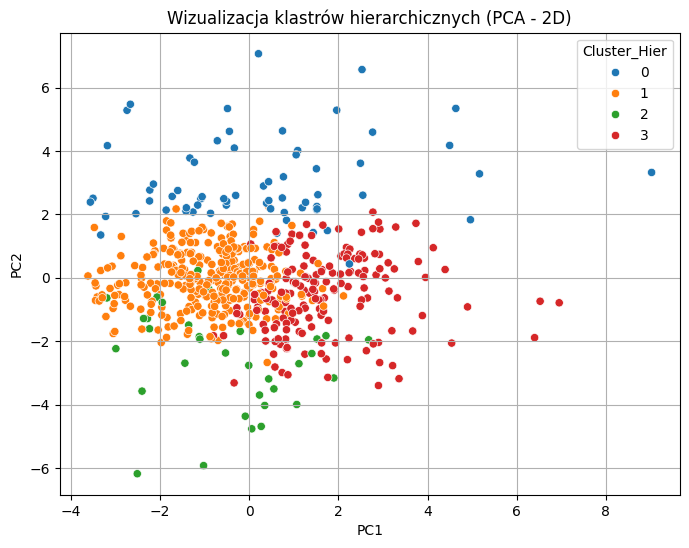

In [14]:
pca = PCA(n_components=2)
components_hier = pca.fit_transform(X_scaled)

# DataFrame
pca_df_hier = pd.DataFrame(components_hier, columns=['PC1', 'PC2'])
pca_df_hier['Cluster_Hier'] = labels_hier  # z AgglomerativeClustering

# Wykres
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df_hier, x='PC1', y='PC2', hue='Cluster_Hier', palette='tab10')
plt.title('Wizualizacja klastrów hierarchicznych (PCA - 2D)')
plt.grid(True)
plt.show()

#### Metoda sieci Kohonena (SOM)

In [15]:
from minisom import MiniSom
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

grid_sizes = [(2, 2), (3, 1), (3, 2), (4, 1), (4, 2)]  # lista wymiarów siatki SOM

results = []

for x_size, y_size in grid_sizes:
    som = MiniSom(x=x_size, y=y_size, input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
    som.train_batch(X_scaled, num_iteration=1000, verbose=False)

    winner_coords = np.array([som.winner(x) for x in X_scaled])
    cluster_labels = [f"{x[0]}_{x[1]}" for x in winner_coords]
    _, cluster_ids = np.unique(cluster_labels, return_inverse=True)

    sil = silhouette_score(X_scaled, cluster_ids)
    ch = calinski_harabasz_score(X_scaled, cluster_ids)
    db = davies_bouldin_score(X_scaled, cluster_ids)

    results.append({
        'Grid': f"{x_size}x{y_size}",
        'Clusters': len(np.unique(cluster_ids)),
        'Silhouette': round(sil, 3),
        'Calinski-Harabasz': round(ch, 1),
        'Davies-Bouldin': round(db, 3)
    })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)
display(results_df.round(3))


,Grid,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2x2,4,0.185,111.8,1.483
3,4x1,4,0.181,105.8,1.603
1,3x1,3,0.175,109.7,1.672
4,4x2,8,0.168,101.5,1.346
2,3x2,6,0.152,101.9,1.509


Najlepszy wynik uzyskano dla siatki 2x2 — najwyższy Silhouette score (0.185) i Calinski-Harabasz (111.8), co wskazuje na najbardziej spójne i dobrze rozdzielone klastry. Siatka 4x2 osiągnęła najniższy Davies-Bouldin (1.346), lecz przy większej liczbie klastrów. Drugi w kolejności niski wynik Davies-Bouldin (1.483) miała siatka 2x2 i to ona ostatecznie wydaje się być najkorzystniejszym kompromisem między liczbą klastrów a jakością podziału. Dlatego w analizie z wykorzystaniem sieci Kohonena  zdecydowano się na siatkę 2x2, a więc liczbę klastrów = 4.  

In [16]:
# Trening sieci Kohonena (MiniSom)
som = MiniSom(x=2, y=2, input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train_batch(X_scaled, num_iteration=1000, verbose=True)

# Przypisanie obserwacji do neuronów
winner_coords = np.array([som.winner(x) for x in X_scaled])
cluster_labels = [f"{x[0]}_{x[1]}" for x in winner_coords]
_, cluster_ids = np.unique(cluster_labels, return_inverse=True)

# Dodanie etykiet
X['Cluster_SOM'] = cluster_ids
df_cleaned_clustered_som = df_cleaned.loc[X.index].copy()
df_cleaned_clustered_som['Cluster_SOM'] = cluster_ids


# Wyświetlenie statystyk klastrów
print(X.groupby('Cluster_SOM').mean().round(2))
print("\nLiczność klastrów:\n", X['Cluster_SOM'].value_counts())

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 2.534743714878538
1            No. of Brands  Brand Runs  Total Volume  No. of  Trans    Value  \
Cluster_SOM                                                                    
0                     2.81        9.62       7181.94          20.33   856.60   
1                     3.40       13.19      23007.95          33.08  2280.42   
2                     3.49       16.94       8921.05          28.25  1014.97   
3                     5.19       26.68      13261.50          48.57  1612.68   

1            Trans / Brand Runs  Vol/Tran  Avg. Price  Pur Vol No Promo - %  \
Cluster_SOM                                                                   
0                          2.74    372.41       12.39                  0.96   
1                          3.84    753.02        9.76                  0.95   
2                          1.92    342.56       11.82                  0.69   
3                          1.93    284.49      

Opis 4 klastrów: 

KLASTER 0 (250) – Umiarkowani i lojalni: Niska liczba marek (2.81), przeciętna liczba transakcji (20.3), najniższa wartość zakupów (856.60). Wysoka lojalność (No Promo = 96%), bardzo mało promocji (Promo 6% = 2%). Dość wysoka cena zakupu (Avg. Price = 12.39). 

KLASTER 1 (110) – Masowi, lojalni i bardzo wartościowi: Duży wolumen (23 008), wysoka liczba transakcji (33.1), najwyższa wartość zakupów (2280.42). Lojalność bardzo wysoka (No Promo = 95%), promocje marginalne. Najniższa średnia cena zakupu (Avg. Price = 9.76). 

KLASTER 2 (83) – Promocyjny segment: Umiarkowana aktywność (Trans = 28.3), przeciętna wartość zakupów (1014.97). Najniższa lojalność (No Promo = 69%), najwyższy udział promocji (Promo 6% = 21%). Średnia cena (Avg. Price = 11.82). 

KLASTER 3 (157) – Najbardziej aktywni: Najwyższa liczba marek (5.19), największa aktywność (Trans = 48.6), wysoka wartość zakupów (1612.68). Wysoka lojalność (No Promo = 92%), niskie wykorzystanie promocji (Promo 6% = 5%). Najdrożej kupujący (Avg. Price = 12.41). 



In [17]:
# Rozkład demograficzny w klastrach
age_dist = df_cleaned_clustered_som.groupby('Cluster_SOM')['AGE'].value_counts(normalize=True).unstack().fillna(0)
sex_dist = df_cleaned_clustered_som.groupby('Cluster_SOM')['SEX'].value_counts(normalize=True).unstack().fillna(0)
sec_dist = df_cleaned_clustered_som.groupby('Cluster_SOM')['SEC'].value_counts(normalize=True).unstack().fillna(0)

age_dist.columns = [f"AGE_{int(c)}" for c in age_dist.columns]
sex_dist.columns = [f"SEX_{int(c)}" for c in sex_dist.columns]
sec_dist.columns = [f"SEC_{int(c)}" for c in sec_dist.columns]

cluster_summary = pd.concat([age_dist, sex_dist, sec_dist], axis=1)
print("\nRozkład demograficzny (procentowy):")
print(cluster_summary.round(2))



Rozkład demograficzny (procentowy):
             AGE_1  AGE_2  AGE_3  AGE_4  SEX_0  SEX_1  SEX_2  SEC_1  SEC_2  \
Cluster_SOM                                                                  
0             0.02   0.26   0.28   0.43   0.22   0.02   0.76   0.30   0.22   
1             0.05   0.14   0.28   0.54   0.02   0.04   0.95   0.13   0.19   
2             0.02   0.19   0.27   0.52   0.10   0.02   0.88   0.25   0.30   
3             0.02   0.20   0.29   0.49   0.03   0.06   0.92   0.25   0.31   

             SEC_3  SEC_4  
Cluster_SOM                
0             0.24   0.24  
1             0.28   0.40  
2             0.22   0.23  
3             0.26   0.18  


Opis 4 klastrów pod względem Wieku, Płci oraz Statusu społeczno-ekonomicznego: 

AGE = 1 — najmłodsi, AGE = 4 — najstarsi 

Klaster 0: 43% AGE 4, 28% AGE 3, 26% AGE 2 – zrównoważony wiekowo, ale dominują starsi 

Klaster 1: 54% AGE 4, 28% AGE 3, 14% AGE 2 – zdecydowanie najstarszy segment 

Klaster 2: 52% AGE 4, 27% AGE 3, 19% AGE 2 – starsi, ale bardziej aktywni 

Klaster 3: 49% AGE 4, 29% AGE 3, 20% AGE 2 – segment dojrzały, z przewagą starszych 

SEX = 0 — mężczyźni, SEX = 2 — kobiety, SEX = 1 — brak danych 

Klaster 0: 76% kobiet, 22% mężczyzn – bardziej zrównoważony, choć kobiety dominują 

Klaster 1: 95% kobiet, 2% mężczyzn – najmocniej sfeminizowany 

Klaster 2: 88% kobiet, 10% mężczyzn – również bardzo sfeminizowany 

Klaster 3: 92% kobiet, 3% mężczyzn – wyraźna dominacja kobiet 

SEC = 1 — najwyższy status społeczno-ekonomiczny, SEC = 4 — najniższy 

Klaster 0: zrównoważony – 30% SEC 1, 24% SEC 3, 24% SEC 4 

Klaster 1: raczej niższe warstwy – 40% SEC 4, 28% SEC 3, tylko 13% SEC 1 

Klaster 2: umiarkowany – 25% SEC 1, 30% SEC 2, 23% SEC 4 

Klaster 3: przeciętny – 25% SEC 1, 31% SEC 2, 26% SEC 3, 18% SEC 4 

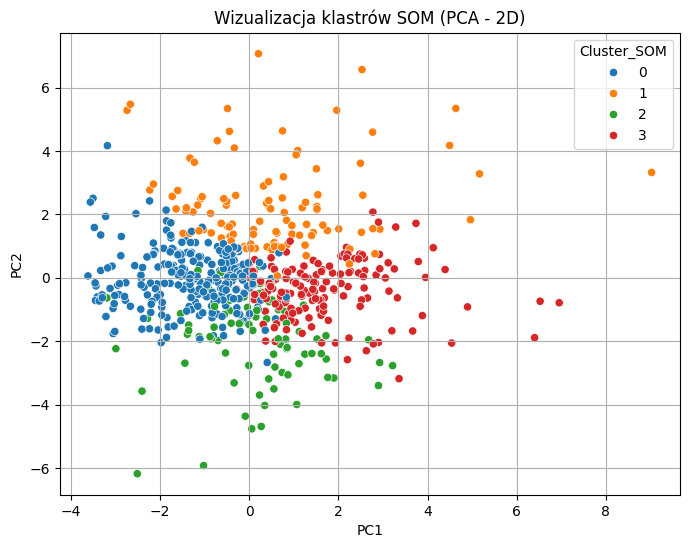

In [18]:
# PCA
pca = PCA(n_components=2)
components_som = pca.fit_transform(X_scaled)

# DataFrame
pca_df_som = pd.DataFrame(components_som, columns=['PC1', 'PC2'])
pca_df_som['Cluster_SOM'] = cluster_ids  # z sieci Kohonena

# Wykres
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df_som, x='PC1', y='PC2', hue='Cluster_SOM', palette='tab10')
plt.title('Wizualizacja klastrów SOM (PCA - 2D)')
plt.grid(True)
plt.show()


### Porównanie i wybór najlepszego 

In [19]:
# Funkcja oceny
def evaluate_clustering(name, labels, data):
    return {
        "Metoda": name,
        "Silhouette": round(silhouette_score(data, labels), 3),
        "Calinski-Harabasz": round(calinski_harabasz_score(data, labels), 1),
        "Davies-Bouldin": round(davies_bouldin_score(data, labels), 3)
    }


# Porównanie metryk
results = [
    evaluate_clustering("KMedoids (k=5)", clusters, X_scaled),
    evaluate_clustering("Hierarchiczne (Ward, k=4)", labels_hier, X_scaled),
    evaluate_clustering("Sieć Kohonena (2x2)", cluster_ids, X_scaled)
]

# Wyświetlenie tabeli
results_df = pd.DataFrame(results)
print("\n Porównanie jakości klasteryzacji:\n")
display(results_df.round(3))




 Porównanie jakości klasteryzacji:



,Metoda,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,KMedoids (k=5),0.135,96.7,1.773
1,"Hierarchiczne (Ward, k=4)",0.187,99.2,1.551
2,Sieć Kohonena (2x2),0.185,111.8,1.483


Najlepszy wynik Silhouette uzyskała metoda hierarchiczna (0.187). Druga w kolejności jest sieć Kohonena (0.185). Niestety obie wartości są poniżej 0.2, co wskazuje na stosunkowo niewielkie odseparowanie klastrów — jednakże jest to typowe w przypadku danych o złożonej strukturze behawioralnej (widoczne jest to również na wykresach PCA). 

Najwyższy Calinski-Harabasz osiągnęła sieć Kohonena (111.8), co oznacza największe zróżnicowanie między klastrami przy relatywnie małym rozrzucie wewnątrz. 

Najniższy Davies-Bouldin również uzyskała SOM (1.483), co dodatkowo potwierdza jej przewagę w jakości podziału. 

Wnioskując sieć Kohonena prezentuje najlepszy kompromis jakościowy między wewnętrzną spójnością a separacją grup i może być uznana za najbardziej efektywną metodę klasteryzacji w tym przypadku. 